# DCT Basis Benchmarks for Neural Image Compression

This notebook demonstrates the core DCT benchmark pipeline: how to evaluate any image codec's **frequency response** using DCT basis matrices as diagnostic inputs.

### What this benchmark reveals

Traditional image quality metrics (PSNR, MS-SSIM) summarize **overall** reconstruction fidelity but hide *which frequency components* a codec distorts. By compressing an $n\times n$ DCT basis matrix — where spatial position uniquely encodes a frequency pair — we obtain a **per-frequency leakage profile** that exposes codec biases invisible to pixel-level metrics.

### Pipeline

```
DCT basis D = DCT(Iₙ)  →  [Codec]  →  D̂  →  R = DCT-domain response  →  L_k, ODR, Δc, σ, H
```

### Key metrics

| Metric | Symbol | Interpretation |
|--------|--------|----------------|
| **Leakage** | $L_k = 1 - R_{k,k}$ | Energy lost from frequency $k$ ↓ better |
| **Off-Diagonal Ratio** | $\text{ODR}_k$ | Energy redistributed to other bands ↓ better |
| **Centroid Shift** | $|\Delta_k|$ | Systematic drift of energy centroid ↓ better |
| **Spread** | $\sigma_k$ | Broadening of response around target ↓ better |
| **Entropy** | $H_k$ | Indiscriminate energy redistribution ↓ better |

---

**Reference:** Kalmykov et al., *DCT Basis Benchmarks for Neural Image Compression: Revealing Frequency-Dependent Biases*, IEEE Signal Processing Letters, 2026.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import torch
from pathlib import Path

from dct_nic import (
    evaluate_codec, load_model, get_available_models,
    build_dct_basis, build_dct_basis_rgb, compute_response_matrix, all_metrics
)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
RESULTS = Path('../results')
print(f'Device: {DEVICE}')

Device: cuda


## 1. DCT Basis Matrix

The $n\times n$ DCT basis matrix $D = \text{DCT}(I_n)$ is the diagnostic input. Each column $d_k$ is a spatial-domain image of the $k$-th DCT basis vector. When arranged as a 2D image, the top-left encodes low frequencies and the bottom-right encodes high frequencies.

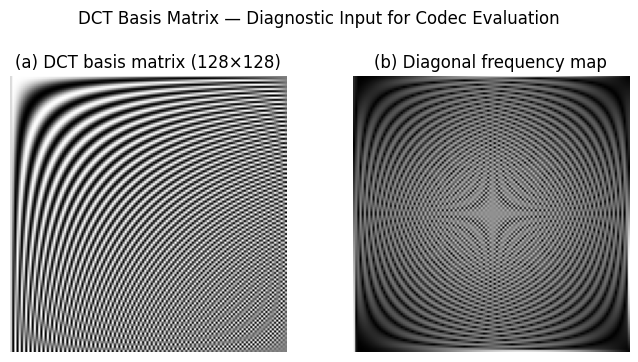

D shape: (128, 128),  range: [-0.125, 0.125]
Top-left = low frequencies, bottom-right = high frequencies
Panel (c) — codec reconstruction — is shown after model evaluation below.


In [3]:
SIZE = 128

D = build_dct_basis(SIZE)
D_rgb, vmin, vmax = build_dct_basis_rgb(SIZE)

# Diagonal-direction frequency map (gradient magnitude of DCT basis).
# Matches Fig. 1(b) in the paper: dark = low frequency, bright = high frequency.
gy, gx = np.gradient(D)
freq_map = np.hypot(gx, gy)
freq_map = (freq_map - freq_map.min()) / (freq_map.max() - freq_map.min() + 1e-9)

fig, axes = plt.subplots(1, 2, figsize=(7, 3.5))
axes[0].imshow(D_rgb.mean(axis=2), cmap='gray')
axes[0].set_title(f'(a) DCT basis matrix ({SIZE}×{SIZE})')
axes[0].axis('off')

axes[1].imshow(freq_map, cmap='gray')
axes[1].set_title('(b) Diagonal frequency map')
axes[1].axis('off')

plt.suptitle('DCT Basis Matrix — Diagnostic Input for Codec Evaluation', y=1.02)
plt.tight_layout()
plt.show()

print(f'D shape: {D.shape},  range: [{D.min():.3f}, {D.max():.3f}]')
print('Top-left = low frequencies, bottom-right = high frequencies')
print('Panel (c) — codec reconstruction — is shown after model evaluation below.')

## 2. Evaluate a Single Codec

Compress the DCT basis, recover the frequency-response matrix $R$, and compute all metrics.

**Custom model interface:** any callable `f(x) → {"x_hat": tensor}` works.

In [ ]:
# Load a model — replace with your own model to test leakage
model = load_model('cheng2020-anchor', quality=6, device=DEVICE)

# Run evaluation
result = evaluate_codec(model, size=SIZE, device=DEVICE, model_name='cheng2020-anchor', num_runs=1)

print(f"Median leakage  L_k      = {result['L_k']:.4f}")
print(f"Low-band leakage L_low   = {result['L_low']:.4f}")
print(f"High-band leakage L_high = {result['L_high']:.4f}")
print(f"Median ODR_k             = {result['ODR_k']:.4f}")
print(f"Median |Δc_k|            = {result['|Δc_k|']:.4f}")
print(f"Median spread σ_k        = {result['s_k']:.4f}")
print(f"Median entropy H_k       = {result['H_k']:.4f}")
print(f"Bitrate                  = {result['bpp']:.3f} bpp" if result['bpp'] else 'Bitrate: N/A')

## 3. Frequency-Response Matrix and Metrics

The $R$ matrix: column $k$ shows where energy from input frequency $k$ ends up after compression. The ideal case is $R = I$ (identity). Deviations reveal codec biases.

In [ ]:
R = result['R']
k = np.arange(SIZE)

fig = plt.figure(figsize=(13, 4.5))
gs = gridspec.GridSpec(1, 3, figure=fig, width_ratios=[1, 1, 1], wspace=0.35)

# (a) Response matrix R
ax0 = fig.add_subplot(gs[0])
im = ax0.imshow(R, origin='lower', cmap='viridis', interpolation='nearest',
                vmin=0, vmax=np.percentile(R, 99))
plt.colorbar(im, ax=ax0, shrink=0.85)
ax0.plot(k, k, 'r--', lw=0.5, alpha=0.5, label='ideal')
ax0.set_xlabel('Input frequency k')
ax0.set_ylabel('Observed frequency i')
ax0.set_title('(a) Frequency-response matrix R')

# (b) Leakage L_k
ax1 = fig.add_subplot(gs[1])
n4 = SIZE // 4
ax1.fill_between(k[:n4], result['leakage'][:n4], alpha=0.15, color='#2D6A2E', label='low')
ax1.fill_between(k[n4:3*n4], result['leakage'][n4:3*n4], alpha=0.15, color='#8B7500', label='mid')
ax1.fill_between(k[3*n4:], result['leakage'][3*n4:], alpha=0.15, color='#A91E1E', label='high')
ax1.plot(k, result['leakage'], '#7E489E', lw=1.5)
ax1.set_xlabel('Frequency index k')
ax1.set_ylabel(r'Leakage $L_k$')
ax1.set_ylim(-0.05, 1.05)
ax1.set_title('(b) Per-frequency leakage')
ax1.legend(fontsize=8)
ax1.grid(True, ls=':', lw=0.4, alpha=0.4)

# (c) All metrics
ax2 = fig.add_subplot(gs[2])
ax2.plot(k, result['leakage'],          label=r'$L_k$', lw=1.3)
ax2.plot(k, result['odr'],              label=r'ODR$_k$', lw=1.3)
ax2.plot(k, np.abs(result['centroid_shift']), label=r'$|\Delta_k|$', lw=1.3)
ax2.plot(k, result['spread'],           label=r'$\sigma_k$', lw=1.3)
ax2.plot(k, result['entropy'],          label=r'$H_k$', lw=1.3)
ax2.set_xlabel('Frequency index k')
ax2.set_title('(c) All metrics')
ax2.set_ylim(-0.05, 1.15)
ax2.legend(fontsize=8, ncol=2)
ax2.grid(True, ls=':', lw=0.4, alpha=0.4)

plt.suptitle('Cheng2020-Anchor  ·  128×128 DCT basis  ·  q=6', y=1.02)
plt.show()

## 4. Compare Original vs Reconstructed

Visually confirm: low-frequency content (top-left) is well preserved; high-frequency content (bottom-right) is strongly attenuated.

In [ ]:
orig = result['orig']    # (n, n, 3) normalized to [0,1]
recon = result['recon']  # (n, n, 3) in original DCT range
recon_disp = np.clip((recon - recon.min()) / (recon.max() - recon.min() + 1e-9), 0, 1)

# Frequency map (gradient magnitude, same as Fig. 1(b) in the paper)
D = build_dct_basis(SIZE)
gy, gx = np.gradient(D)
freq_map = np.hypot(gx, gy)
freq_map = (freq_map - freq_map.min()) / (freq_map.max() - freq_map.min() + 1e-9)

# --- Fig. 1 layout from the paper ---
fig, axes = plt.subplots(1, 3, figsize=(11, 3.5))

axes[0].imshow(orig.mean(axis=2), cmap='gray')
axes[0].set_title('(a) DCT basis matrix')
axes[0].axis('off')

axes[1].imshow(freq_map, cmap='gray')
axes[1].set_title('(b) Frequency map')
axes[1].axis('off')

axes[2].imshow(recon_disp.mean(axis=2), cmap='gray')
axes[2].set_title('(c) Cheng2020-Anchor (q=6)')
axes[2].axis('off')

plt.suptitle(f'Fig. 1 — DCT Benchmark ({SIZE}×{SIZE}): high-frequency attenuation in bottom-right', y=1.02)
plt.tight_layout()
plt.show()

# --- Error map (additional) ---
fig2, ax2 = plt.subplots(figsize=(4, 3.5))
diff = np.abs(orig.mean(axis=2) - recon_disp.mean(axis=2))
im = ax2.imshow(diff, cmap='hot', vmin=0)
plt.colorbar(im, ax=ax2, shrink=0.8)
ax2.set_title('|Error| — high = large distortion')
ax2.axis('off')
plt.tight_layout()
plt.show()

## 5. Evaluating Your Own Model

Any model following the interface `model(x) → {"x_hat": tensor}` can be evaluated:

In [ ]:
# Example: evaluate a custom / identity model
class IdentityCodec:
    """Lossless passthrough — should give L_k ≈ 0."""
    def __call__(self, x):
        return {"x_hat": x}

res_id = evaluate_codec(IdentityCodec(), size=64, device='cpu')
print(f"Identity codec — median L_k: {res_id['L_k']:.6f}  (expected ≈ 0)")

# Template for your own NIC model:
#
#   import torch
#   from dct_nic import evaluate_codec
#
#   class MyNIC(torch.nn.Module):
#       def forward(self, x):            # x: [1, 3, H, W] in [0, 1]
#           ...                          # your encode–decode here
#           return {"x_hat": x_hat}      # x_hat: same shape
#
#   model = MyNIC().eval()
#   result = evaluate_codec(model, size=256, device='cuda')
#   print(f"Leakage: {result['L_k']:.4f}")

## 6. Rate–Leakage Curves (Pre-computed Results)

Fig. 5 from the paper: median leakage $L_k$ vs bitrate for all codecs at $256\times256$.
Traditional codecs (dashed) achieve orders-of-magnitude lower leakage than NIC models across all bitrates.

In [ ]:
csv = RESULTS / 'leakage_vs_bpp' / 'scan_leakage_vs_bpp_256.csv'
df = pd.read_csv(csv)

COLORS = {
    'cheng2020-anchor': '#7E489E', 'cheng2020-attn': '#E883B6',
    'mbt2018-mean': '#717171', 'mbt2018': '#A0BBD4',
    'bmshj2018-hyperprior': '#B8B028', 'bmshj2018-factorized': '#7B4B3D',
    'ftic': '#D82F30', 'tcm': '#F0801F',
    'jpeg': '#287BB8', 'webp': '#429A38', 'jpegxl': '#3AC1CF',
}
LABELS = {
    'cheng2020-anchor': 'Cheng2020-Anchor', 'cheng2020-attn': 'Cheng2020-Attention',
    'mbt2018-mean': 'MBT2018-Mean', 'mbt2018': 'MBT2018',
    'bmshj2018-hyperprior': 'BMSHJ2018-Hyperprior', 'bmshj2018-factorized': 'BMSHJ2018-Factorized',
    'ftic': 'FTIC', 'tcm': 'TCM',
    'jpeg': 'JPEG', 'webp': 'WebP', 'jpegxl': 'JPEG XL',
}
TRADITIONAL = {'jpeg', 'webp', 'jpegxl'}

fig, ax = plt.subplots(figsize=(7, 4))
for name, grp in df.groupby('model'):
    grp = grp.sort_values('bpp')
    ls = '--' if name in TRADITIONAL else '-'
    ax.semilogy(grp['bpp'], grp['L_k'], ls, color=COLORS.get(name, 'gray'),
                marker='o', markersize=4, lw=1.5, label=LABELS.get(name, name))

ax.set_xlabel('Bitrate (bpp)', fontsize=11)
ax.set_ylabel(r'Median leakage $L_k$ (↓ better)', fontsize=11)
ax.set_title('Rate–Leakage Comparison  ·  256×256 DCT basis', fontsize=12)
ax.legend(fontsize=8, ncol=2, loc='upper right')
ax.grid(True, which='both', ls=':', lw=0.4, alpha=0.5)
plt.tight_layout()
plt.show()

## 7. All-Metrics Overview: 3D Surface Plots

Median leakage $L_k$ as a function of image size and quality, for the Cheng2020 family.

In [ ]:
df_all = pd.read_csv(RESULTS / 'all_metrics_summary.csv')
print('Columns:', df_all.columns.tolist())
print(df_all.head())

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

METRIC = 'L_k'
MODELS_3D = ['cheng2020-anchor', 'cheng2020-attn', 'bmshj2018-factorized', 'mbt2018']
SIZES_3D = [64, 128, 256, 512]
QUALITIES_3D = [1, 2, 3, 4, 5, 6]

fig = plt.figure(figsize=(14, 4))
for idx, model_name in enumerate(MODELS_3D):
    ax = fig.add_subplot(1, len(MODELS_3D), idx + 1, projection='3d')
    sub = df_all[df_all['Model'] == model_name]
    X, Y = np.meshgrid(QUALITIES_3D, SIZES_3D)
    Z = np.full_like(X, np.nan, dtype=float)
    for qi, q in enumerate(QUALITIES_3D):
        for si, sz in enumerate(SIZES_3D):
            row = sub[(sub['q'] == q) & (sub['Size'] == f'{sz}x{sz}')]
            if not row.empty and METRIC in row.columns:
                Z[si, qi] = float(row[METRIC].iloc[0])
    mask = ~np.isnan(Z)
    if mask.any():
        ax.plot_surface(X, Y, Z, cmap=cm.viridis, alpha=0.85, linewidth=0)
    ax.set_xlabel('q', fontsize=7)
    ax.set_ylabel('size', fontsize=7)
    ax.set_zlabel(METRIC, fontsize=7)
    ax.set_title(LABELS.get(model_name, model_name).replace('\n', '\n'), fontsize=8)
    ax.tick_params(labelsize=6)

plt.suptitle(f'Median leakage $L_k$ vs quality and size', y=1.02)
plt.tight_layout()
plt.show()

## 8. Spectral Leakage Coupling on Natural Images

The spectral leakage coupling $\tilde{\mathcal{L}}$ links the codec's DCT-domain leakage profile to distortion on real images (Table I in the paper).

In [ ]:
from dct_nic import spectral_leakage_coupling

kodak_csv = RESULTS / 'kodak_eval' / 'kodak_per_image.csv'
if kodak_csv.exists():
    df_kodak = pd.read_csv(kodak_csv)
    clean = df_kodak[df_kodak['distortion'] == 'codec_clean']
    agg = clean.groupby('model').agg(
        mean_psnr=('psnr', 'mean'),
        mean_Le=('Le', 'mean'),
        mean_rho_bar=('rho_bar', 'mean'),
    ).round(4)
    print('Spectral leakage coupling on 24 Kodak images (codec_clean, q=6):')
    print(agg.sort_values('mean_Le', ascending=False).to_string())
else:
    print('Pre-computed Kodak results not found.')
    print('Generate: python scripts/run_kodak_eval.py --kodak-dir data/kodak')
    print('\nManual example:')
    print('   from dct_nic import spectral_leakage_coupling, evaluate_codec')
    print('   res = evaluate_codec(model, size=512)')
    print('   sc = spectral_leakage_coupling(orig_gray, recon_gray, res["leakage"])')
    print('   print(sc["L_tilde"], sc["ratio"])')